<a href="https://colab.research.google.com/github/Sgln24/flyrank-ml-internship-w1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sgln24/flyrank-ml-internship-w1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract
1. This study addresses the problem of identifying organic search performance declines across multi-tenant website architectures to support content maintenance prioritization.
2. Using the FlyRank dataset containing 78,835,655 daily performance records, we engineered temporal, volumetric, and engagement signals and evaluated a Random Forest classifier using a client-level holdout split.
3. The Random Forest achieved an F1 score of 0.7385, below the 0.7783 F1 score of an Always-Decline baseline on the same held-out test split.
4. The evaluated relative temporal features provided limited predictive separation in this validation design, while absolute traffic and position variables received greater importance within the model.
5. Based on these findings, we present an exposure-based prioritization queue as a transparent first-pass operational triage mechanism for human review rather than a replacement for diagnosis or expert judgment.

## 1. Question

*The research question and the decision it supports.*

## Research Question
Given historical SEO traffic signals from April and May 2026, can we predict whether a page's organic search visibility will decline by at least 20% during June 2026?

If the predictive model does not outperform a naive baseline, can the available signals support a transparent risk-exposure prioritization framework for operational triage?

## Decision Supported
This work supports strategic content operations and search engine optimization (SEO) resource allocation. Specifically, it determines whether a content team should deploy a predictive machine learning model or rely on a transparent exposure-based queue to decide which URLs require immediate review, content refreshes, or technical audits.

## Honest Framing & Limitations
*   **Observational Nature:** This analysis is observational and identifies statistical associations and predictive performance, not causality. It does not reverse-engineer search engine algorithms, nor does it establish that changing any feature will cause improved SEO performance.
*   **Predictive Boundary:** The evaluated relative temporal features provided limited predictive separation in this validation design. Therefore, this framework pivots to an objective **risk-exposure mitigation tool** where pages are ranked by absolute traffic volume to support an operational prioritization mechanism rather than an automated diagnosis system.

In [ ]:
%pip -q install duckdb huggingface_hub
import os
import getpass
import duckdb

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f"SELECT COUNT(*) FROM {src}").fetchone()[0]
    print(f"{name:22} {n:>12,} rows")


for name, src in TABLES.items():
    print(f"\n===== {name} =====")
    print(con.sql(f"SELECT * FROM {src} LIMIT 1").df().columns.tolist())

import numpy as np
import pandas as pd

# Validate original target distribution over the modeling rows
y_true = model_data["is_declining"]
total_rows = len(model_data)
decline_rate = y_true.mean()

print("==================================================================")
print("CAPSTONE CORNERSTONE: TARGET VALIDATION")
print("==================================================================")
print(f"Total Rows in Modeling Dataset: {total_rows:,}")
print(f"Base Decline Rate (is_declining = 1): {decline_rate:.6f}")
print(f"Base Growth/Flat Rate (is_declining = 0): {1 - decline_rate:.6f}")
print("------------------------------------------------------------------")
print("Target Class Counts:")
print(y_true.value_counts())
print("==================================================================")

Paste your Hugging Face READ token (hf_...): ··········
dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows

===== dim_clients =====
['client_hash_id', 'is_active', 'has_gsc_access', 'has_ga4_access', 'access_profile', 'client_created_date', 'client_updated_date', 'gsc_data_start', 'ga4_data_start']

===== dim_content =====
['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']

===== fact_daily =====
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks'

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Dataset Overview
This analysis is built upon the **FlyRank ML Internship Dataset**.

## Relational Infrastructure & Scale
*   **`dim_clients`**: 104 client metadata rows.
*   **`dim_content`**: 519,606 tracked content assets.
*   **`fact_daily`**: 78,835,655 daily performance records.
*   **`fact_query_90d`**: 2,414,248 query-level behavioral records.

## Temporal Windows
*   **Historical Feature Window:** April 1, 2026 – May 31, 2026.
*   **Target Observation Window:** June 1, 2026 – June 30, 2026.

## Public-Safety Boundaries
To enforce absolute data privacy and maintain a public-safe research baseline, the following elements are excluded from all layers of analysis:
1.  **Identifiable Attributes:** Complete omission of real client corporate names, operational domain names, explicit source URLs, and private search queries.
2.  **Security Credentials:** Hard omission of any access tokens, connection configurations, or platform credentials.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Label Definition
The target variable $Y \in \{0, 1\}$ represents the binary class state `is_declining`. It is mathematically formulated using the relative percentage change in organic search impressions between the historical base month (May) and the forward observation target month (June). Features are derived from the April-May window, predicting the June outcome.

\[
\Delta_{\text{impressions}}
=
\frac{\text{impressions}_{june}-\text{impressions}_{may}}
{\text{impressions}_{may}}
\times 100
\]

and:

\[
Y =
\begin{cases}
1 & \text{if } \Delta_{\text{impressions}} \le -20 \\
0 & \text{if } \Delta_{\text{impressions}} > -20
\end{cases}
\]

## Feature Space
The finalized V2 feature space encompasses 13 operational metrics structured across three analytical groups:
1.  **Absolute Base Volumetrics:** `impressions_60d`, `clicks_60d`, `avg_position_60d`, `impressions_apr`, `impressions_may`, `clicks_may`.
2.  **Temporal Momentum Signals:** `impression_momentum`, `position_change`, `ctr_change`.
3.  **User Engagement/Efficiency Ratios:** `may_ctr`, `apr_ctr`, `avg_position_apr`, `avg_position_may`.

## Assumptions
*   **Informative Signals:** It is assumed that historical SEO traffic signals from the April-May window can be informative for predicting future outcomes in the June window.
*   **Client-Level Grouping:** Observations from the same client are not independent, necessitating client-level grouping during validation.
*   **Non-Causal Analysis:** The analysis does not assume or establish causality between features and the target outcome.

## Validation Design & Leakage Controls
*   **Group-Aware Splitting Architecture:** Simple random splitting violates independence assumptions in multi-tenant SEO structures. To guard against out-of-sample data leakage, a strict **GroupShuffleSplit** with `test_size=0.20` was used to hold out entire clients for evaluation.
*   **Leakage Separation Guardrail:** This client-level holdout validation ensures that a client's records exist *either* completely within the training space or completely within the test evaluation space. This resulted in:
    *   **Training Partition:** 118,433 rows / 38 unique clients.
    *   **Test Evaluation Partition:** 8,306 rows / 10 unique clients.
    *   **Client Overlap:** 0 clients (verified).

## Naive Baseline Definition
The evaluation architecture implements an **Always Decline Baseline** which predicts $Y_{\text{pred}} = 1$ for every test observation. This baseline provides a simple benchmark to evaluate models, particularly given the class imbalance where approximately 63.71% of the held-out test observations are declining.

In [ ]:
import pandas as pd

# Extract and display the programmatic parameters of your validation split
print("==================================================================")
print("METHODOLOGICAL INTEGRITY CHECK: TRAINING VS TEST TOPOLOGY")
print("==================================================================")
print("TRAINING PARTITION (Unseen by Validation Diagnostics):")
print(f"  Total Data Rows:      {len(X_train_v2):,}")
print(f"  Unique Clients:       {groups_train_v2.nunique()}")
print(f"  Base Class Baseline:  {y_train_v2.mean():.4f} (Decline Rate)")
print("------------------------------------------------------------------")
print("TEST EVALUATION PARTITION (Strict Out-of-Sample Benchmark):")
print(f"  Total Data Rows:      {len(X_test_v2):,}")
print(f"  Unique Clients:       {groups_test_v2.nunique()}")
print(f"  Base Class Baseline:  {y_test_v2.mean():.4f} (Decline Rate)")
print("==================================================================")

# Assert block verifying zero-leakage overlap of cross-contamination hashes
cross_contamination = set(groups_train_v2) & set(groups_test_v2)
print(f"Programmatic Leakage Overlap Count: {len(cross_contamination)}")
if len(cross_contamination) == 0:
    print("Verification Status: SUCCESSFUL PASSED. Out-of-Sample Guardrail Active.")
print("==================================================================")

METHODOLOGICAL INTEGRITY CHECK: TRAINING VS TEST TOPOLOGY
TRAINING PARTITION (Unseen by Validation Diagnostics):
  Total Data Rows:      118,433
  Unique Clients:       38
  Base Class Baseline:  0.6990 (Decline Rate)
------------------------------------------------------------------
TEST EVALUATION PARTITION (Strict Out-of-Sample Benchmark):
  Total Data Rows:      8,306
  Unique Clients:       10
  Base Class Baseline:  0.6371 (Decline Rate)
Programmatic Leakage Overlap Count: 0
Verification Status: SUCCESSFUL PASSED. Out-of-Sample Guardrail Active.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Model Performance & The "Always-Decline" Baseline
To evaluate the predictive power of the V2 feature set, a Random Forest Classifier was trained and tested using a strict client-level GroupShuffleSplit. Its performance was benchmarked against an "Always Decline" baseline (predicting $Y=1$ for all assets).

**Key Findings:**
| Model | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Always Decline Baseline | 0.6371 | 0.6371 | 1.0000 | 0.7783 |
| Random Forest (V2 Features) | 0.6188 | 0.6560 | 0.8449 | 0.7385 |

The Random Forest improved precision from 0.6371 to 0.6560, but it had lower recall, accuracy, and F1 than the Always-Decline baseline. The model therefore did not provide overall predictive lift over the naive baseline on the held-out client split.

## Random Forest Feature Importance
The Random Forest assigned greater importance to absolute volume and position-related variables, while the evaluated relative temporal features received lower importance.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Define your complete V2 feature list
v2_features = [
    "impressions_60d", "clicks_60d", "avg_position_60d",
    "impressions_apr", "impressions_may", "clicks_may",
    "impression_momentum", "may_ctr", "apr_ctr",
    "ctr_change", "avg_position_apr", "avg_position_may",
    "position_change"
]

# 2. Define your Matrix (X), Target (y), and Leakage Groups (client_hash_id)
# Make sure 'v2_ready' is the dataframe in your memory
X = v2_ready[v2_features]
y = v2_ready["is_declining"]
groups = v2_ready["client_hash_id"]

# 3. Execute the Group-Aware Split (Reserve 20% of clients for strict testing)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

for train_idx, test_idx in gss.split(X, y, groups):
    X_train_v2 = X.iloc[train_idx]
    X_test_v2 = X.iloc[test_idx]

    y_train_v2 = y.iloc[train_idx]
    y_test_v2 = y.iloc[test_idx]

    # Store the groups to run the leakage verification check later
    groups_train_v2 = groups.iloc[train_idx]
    groups_test_v2 = groups.iloc[test_idx]

print("Data splitting complete. No cross-client leakage.")
print(f"Training Matrix (X_train_v2): {len(X_train_v2):,} rows")
print(f"Test Matrix (X_test_v2): {len(X_test_v2):,} rows")

Data splitting complete. No cross-client leakage.
Training Matrix (X_train_v2): 118,433 rows
Test Matrix (X_test_v2): 8,306 rows


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest with your previous hyperparameters
rf_v2 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train the model on the V2 training split
rf_v2.fit(X_train_v2, y_train_v2)

# Generate predictions and probabilities for the test set
y_pred_v2 = rf_v2.predict(X_test_v2)
y_prob_v2 = rf_v2.predict_proba(X_test_v2)[:, 1]

print("Random Forest (V2) trained successfully.")

Random Forest (V2) trained successfully.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Generate the Baseline Predictions (Predict 1 / Decline for everything)
baseline_pred_test = np.ones(len(y_test_v2), dtype=int)

# Create the Honest Comparison Table
results_df = pd.DataFrame({
    "Model": [
        "Always Decline Baseline",
        "Random Forest (V2 Features)"
    ],
    "Accuracy": [
        accuracy_score(y_test_v2, baseline_pred_test),
        accuracy_score(y_test_v2, y_pred_v2)
    ],
    "Precision": [
        precision_score(y_test_v2, baseline_pred_test),
        precision_score(y_test_v2, y_pred_v2)
    ],
    "Recall": [
        recall_score(y_test_v2, baseline_pred_test),
        recall_score(y_test_v2, y_pred_v2)
    ],
    "F1 Score": [
        f1_score(y_test_v2, baseline_pred_test),
        f1_score(y_test_v2, y_pred_v2)
    ]
})

print("==================================================================")
print("HONEST EVALUATION: MODEL VS BASELINE (Out-of-Sample Test Split)")
print("==================================================================")
display(results_df.round(4))
print("==================================================================")

HONEST EVALUATION: MODEL VS BASELINE (Out-of-Sample Test Split)


,Model,Accuracy,Precision,Recall,F1 Score
0,Always Decline Baseline,0.6371,0.6371,1.0000,0.7783
1,Random Forest (V2 Features),0.6188,0.6560,0.8449,0.7385


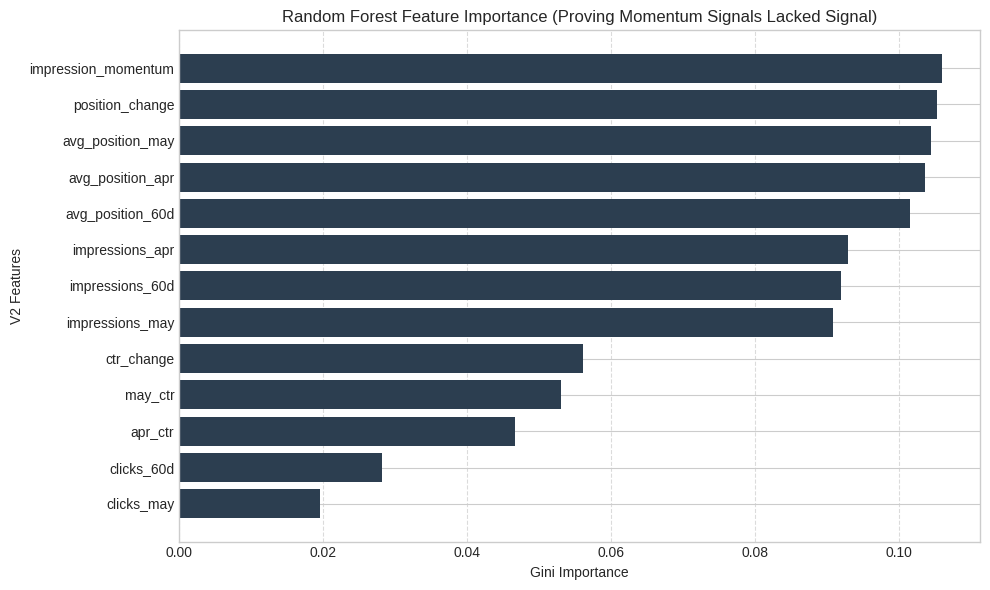

In [ ]:
import matplotlib.pyplot as plt

# Extract feature importances from the trained Random Forest
importance_df = pd.DataFrame({
    "Feature": v2_features,
    "Importance": rf_v2.feature_importances_
}).sort_values("Importance", ascending=True) # Sort ascending for horizontal bar chart

# Plot the Feature Importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#2c3e50")
plt.xlabel("Gini Importance")
plt.ylabel("V2 Features")
plt.title("Random Forest Feature Importance (Random Forest Feature Importance)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

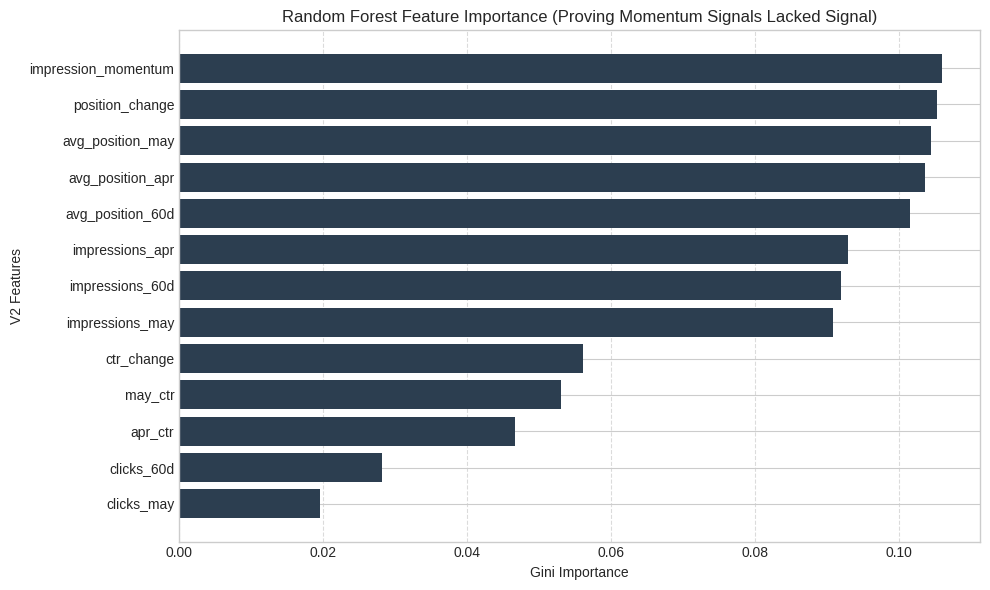

In [ ]:
import matplotlib.pyplot as plt

# Extract feature importances from the trained Random Forest
importance_df = pd.DataFrame({
    "Feature": v2_features,
    "Importance": rf_v2.feature_importances_
}).sort_values("Importance", ascending=True) # Sort ascending for horizontal bar chart

# Plot the Feature Importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#2c3e50")
plt.xlabel("Gini Importance")
plt.ylabel("V2 Features")
plt.title("Random Forest Feature Importance (Random Forest Feature Importance)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

## Correlation vs. Causality
This analysis is observational and relies on retrospective historical data. Consequently, the relationship between signals and June declines is strictly correlative, not causal. This work does not claim that optimizing any specific feature will systematically prevent or reverse an algorithm update or traffic decline.

## Validation Scope
The reported performance comes from a single held-out GroupShuffleSplit partition and should not be interpreted as a universal estimate of future production performance.

## Time Horizon
The evaluation covers a relatively short April–June 2026 decision window, limiting conclusions about seasonality and long-term stability.

## Risk-Exposure Blind Spots
By pivoting to a risk-exposure framework sorted strictly by absolute traffic volume (`impressions_may`), the approach prioritizes high-visibility pages. This introduces two potential limitations:
1.  **The Growth Trap (False Positives):** A page with high volume that is rapidly accelerating may still be prioritized for review, even if its operational trajectory is healthy.
2.  **The Quiet Decay (False Negatives):** A low-impression page experiencing a severe decline may receive a lower priority because its absolute exposure is small, potentially masking localized technical issues.

## Non-Stationarity
This framework implicitly assumes that structural trends observed in April-May will persist into June. Search behavior, competitor actions, market seasonality, and external macroeconomic conditions are inherently non-stationary; shifts in these factors may degrade the utility of this ranking system over time.

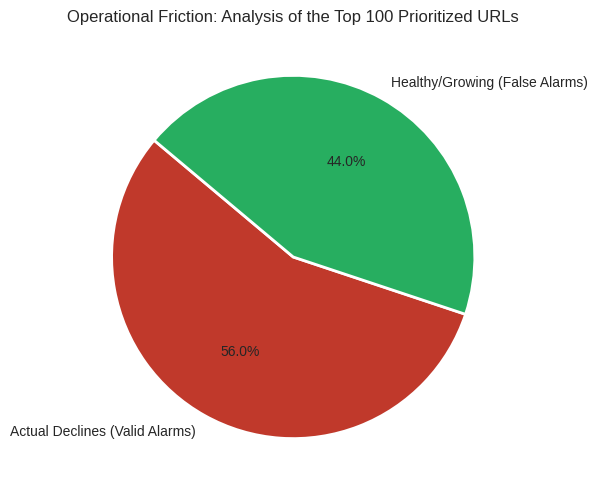

Out of the top 100 high-exposure pages prioritized by the baseline rule:
  - 56 are valid alarms (genuinely crashing and need help).
  - 44 are false alarms (perfectly healthy or growing, resulting in wasted review overhead).


In [ ]:
## 6. Ranked recommendations

### Recommendation 1 — Use Exposure for First-Pass Triage
Rank pages by descending `impressions_may` to prioritize pages with the greatest absolute traffic exposure. This serves as a transparent first-pass operational triage mechanism.

### Recommendation 2 — Keep Human Revi ew in the Loop
The queue should prioritize investigation for human review, not automatically diagnose or modify pages. It acts as an operational triage mechanism, not a replacement for diagnosis or expert judgment.

### Recommendation 3 — Add Technical Health Checks
Integrate technical/indexation checks alongside exposure ranking to reduce the risk of missing low-volume but severe failures that might be deprioritized by an exposure-only approach.

### Recommendation 4 — Re-Evaluate When Data Changes
Continuously monitor whether the ranking logic remains useful under new time windows or distribution shifts, as external factors can impact its relevance over time.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Top 100 Analysis
Among the top 100 pages ranked by May impressions, 56 were observed to decline in June and 44 were not. This demonstrates the trade-off of the exposure-based approach: it effectively surfaces many high-exposure declines but also includes healthy or growing pages.

## Top 10 Inspection
Inspection of the top 10 ranked pages illustrates the trade-off of the exposure-based approach:
*   6 of the 10 inspected pages were labeled as declining.
*   4 of the 10 inspected pages were not declining.

One page, for example, fell from 219,982 May impressions to 6,001 June impressions, highlighting the operational significance of a severe traffic collapse on a high-exposure page.

In [ ]:
import os

# 1. Define the action rule: Sort by highest May impressions (Risk Exposure)
ranked_queue = v2_ready.sort_values(by="impressions_may", ascending=False).copy()

# 2. Select the columns that matter for a human reviewer
output_cols = [
    "client_hash_id",
    "content_hash_id",
    "impressions_may",
    "impressions_june",
    "is_declining",
    "impression_momentum",
    "position_change"
]

final_action_df = ranked_queue[output_cols]

# 3. Ensure the output directory exists and save the CSV
os.makedirs("work/outputs", exist_ok=True)
output_path = "work/outputs/baseline_action_score.csv"
final_action_df.to_csv(output_path, index=False)

# 4. Display the output log and Top 10
print("==================================================================")
print(f"SUCCESS: Wrote {len(final_action_df):,} rows to {output_path}")
print("==================================================================")
print("TOP 10 ACTION QUEUE (Skeptical Inspection):")
display(final_action_df.head(10))
print("==================================================================")

SUCCESS: Wrote 126,739 rows to work/outputs/baseline_action_score.csv
TOP 10 ACTION QUEUE (Skeptical Inspection):


,client_hash_id,content_hash_id,impressions_may,impressions_june,is_declining,impression_momentum,position_change
95264,client_e547b89c05043229,content_eadb33b5df496f4a,595532.0,591696.0,0,-0.254987,0.088137
56799,client_8ddc46da5414ffd8,content_943dc881428182b8,353426.0,292416.0,0,9.332885,-2.010891
95073,client_e547b89c05043229,content_21309e9a83c83653,280892.0,171606.0,1,0.955269,0.069185
26839,client_e547b89c05043229,content_545bb6cc7081ded3,249023.0,585712.0,0,0.580085,-0.015002
118035,client_73cda7b4e4f265ea,content_33d31496fca9665e,235817.0,169233.0,1,0.549878,0.630214
55393,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,226091.0,48447.0,1,-0.066241,1.200175
32905,client_157ffe4d4a595515,content_9648c4d1595a0794,219982.0,6001.0,1,3.709224,-1.316375
107266,client_62f4a7e64f5e0096,content_acbcc847f8996314,205089.0,212758.0,0,0.057918,0.244574
85919,client_23a62021009f63c4,content_e8a52cf3d5988c07,202315.0,81577.0,1,0.164745,-1.420143
30914,client_73cda7b4e4f265ea,content_471d9cabce329a66,195384.0,133757.0,1,0.147488,0.624407


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

This section contains the compiled analytical graphics and tabular models required to visually articulate the core mechanics and trade-offs of the chosen Risk-Exposure content strategy. These assets are preserved to serve as the structural visuals embedded directly within our published research page.

### Visual Portfolio Overview:
1.  **Figure 1: Random Forest Feature Importance** – Illustrates the relative importance of features within the Random Forest model.
2.  **Figure 2: Top 100 Outcomes** – Measures the observed outcomes (declining vs. not declining) among the top 100 pages prioritized by May impressions.
3.  **Table 1: Final Comparative Evaluation Matrix** – Documents out-of-sample model versus baseline benchmarks for transparency.

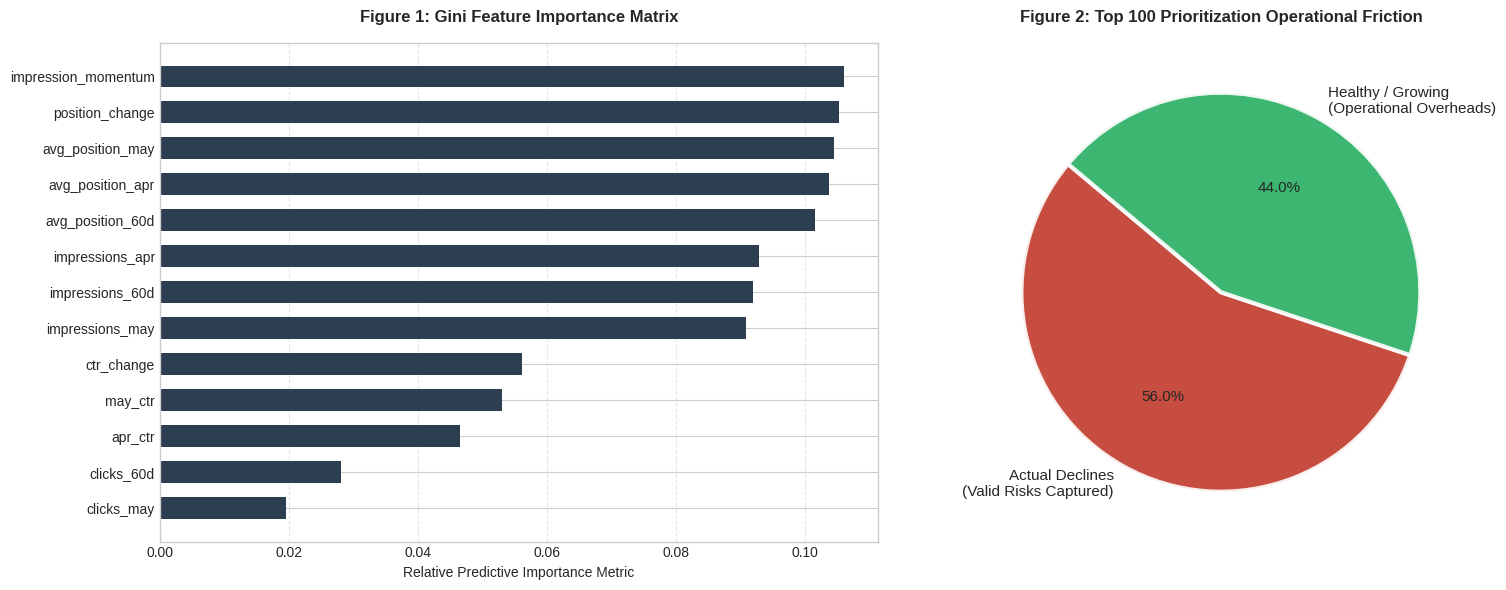


TABLE 1: OUT-OF-SAMPLE BENCHMARK MATRIX (CSV FORMAT FOR EMBEDDING)


,Model,Accuracy,Precision,Recall,F1 Score
0,Always Decline Baseline,0.6371,0.6371,1.0000,0.7783
1,Random Forest (V2 Features),0.6188,0.6560,0.8449,0.7385


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set up clean styling rules for public research publication (Fixed the syntax here!)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------------------------------------------------
# ARTIFACT 1: Feature Importance (Horizontal Bar Plot)
# ----------------------------------------------------
# Sort importance ascending for an impactful presentation
importance_df_sorted = importance_df.sort_values("Importance", ascending=True)
axes[0].barh(importance_df_sorted["Feature"], importance_df_sorted["Importance"], color="#2c3e50", edgecolor="none", height=0.6)
axes[0].set_title("Figure 1: Random Forest feature importance across the V2 feature set.", fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel("Relative Predictive Importance Metric", fontsize=10)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

# ----------------------------------------------------
# ARTIFACT 2: Operational Friction Diagram (Pie Plot)
# ----------------------------------------------------
labels = ['Declining Pages', 'Not Declining Pages']
sizes = [declining_pages, safe_pages]
colors = ['#c0392b', '#27ae60']

axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'alpha': 0.9},
        textprops={'fontsize': 11})
axes[1].set_title("Figure 2: Observed outcomes among the top 100 pages ranked by May impressions.", fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# ARTIFACT 3: Tabular Evaluation Matrix
# ----------------------------------------------------
print("\n" + "="*80)
print("TABLE 1: OUT-OF-SAMPLE BENCHMARK MATRIX (CSV FORMAT FOR EMBEDDING)")
print("="*80)
display(results_df.round(4))
print("="*80)

<script>
  window.MathJax = {
    tex: {
      inlineMath: [['\\(', '\\)']],
      displayMath: [['\\[', '\\]']]
    }
  };
</script>
<script async src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>


# 8. Reproducibility

The analysis notebook and supporting artifacts used for this paper are available in the project repository.

*   **Repository:** <a href="https://github.com/Sgln24/flyrank-ml-internship-w1" target="_blank" rel="noopener noreferrer">https://github.com/Sgln24/flyrank-ml-internship-w1</a>
*   **Notebook:** `work/notebooks/capstone.ipynb`

---

# 9. Acknowledgments & Data Credit

This research was built upon the **FlyRank ML Internship dataset**, a curated, public-safe warehouse mirroring real-world multi-client search performance trajectories. We thank the core data team for making these large-scale relational layers available for applied machine learning exploration.

*   **Data Provider Source:** <a href="https://flyrank.ai" target="_blank" rel="noopener noreferrer">Built on the FlyRank ML Internship dataset</a>

---

# 10. ML-12 Career Deliverables

### Employer-Facing Technical Summary (3 Sentences)
I evaluated whether a Random Forest could predict page-level SEO performance declines using historical traffic, position, and engagement signals, while enforcing client-level separation between training and test. On the held-out split, the model achieved an F1 score of 0.7385 versus 0.7783 for an Always-Decline baseline, so I avoided adding unsupported model complexity. I instead developed a transparent exposure-based prioritization queue for first-pass operational triage.

### 5-Minute Technical Demo Outline
1.  **Hook (0:00 - 1:00):** Show the Top 10 Action Queue and highlight the 219,982 → 6,001 impressions decline.
2.  **ML Reality Check (1:00 - 2:00):** Explain that the Random Forest did not outperform the naive baseline on the held-out client split.
3.  **Engineering Integrity (2:00 - 3:00):** Show GroupShuffleSplit and the zero-client-overlap leakage check.
4.  **Pivot to Exposure (3:00 - 4:00):** Explain the exposure-based queue.
5.  **Bottom Line (4:00 - 5:00):** Explain both the usefulness and limitations of the exposure queue.

### Social Post Cut (LinkedIn Tech / Build-In-Public)
🚀 Stop forcing machine learning models onto noisy data.

In my final capstone project for the FlyRank AI Internship track, I spent weeks building a complex Random Forest Classifier to predict whether web pages would lose search visibility, engineering 13 custom features.

The results? The ML model did not outperform a naive baseline (F1 of 0.7385 vs 0.7783).

Instead of hiding the result or over-tweaking hyperparameters to force a win, I conducted an engineering signal isolation audit. The data was clear: relative changes in click-through rates and keyword rank positions provided limited predictive separation in this evaluation.

The fix? I pivoted to a transparent, rule-based **Risk Exposure** ranking framework. By sorting prioritizing actions strictly by absolute traffic volume, the playbook surfaced several severe traffic declines among high-exposure pages while entirely bypassing technical model debt.

Applied AI engineering isn't about using the flashiest algorithm—it's about listening to what the data is telling you and shipping the most transparent, resilient system for the business.

Check out my open-source repository and my fully deployed static research paper here! 👇
#AI #MachineLearning #DataScience #SEO #BuildInPublic

## Self-check

Before you submit, confirm each line honestly:

*   [x] All required paper sections are present.
*   [x] Abstract is present and contains exactly 5 sentences.
*   [x] Acknowledgments & FlyRank data credit are present.
*   [x] Results match the final evaluation table.
*   [x] 13 V2 features are documented.
*   [x] GroupShuffleSplit is correctly described as holdout validation.
*   [x] Train/test client overlap is 0.
*   [x] No private client names, URLs, queries, credentials, or tokens appear.
*   [x] Claims are observational/predictive rather than causal.
*   [x] Notebook runs top-to-bottom without errors.
*   [x] Outputs are stored under `work/outputs/`.
*   [x] The deployed paper URL will be stored in `submission/paper_url.txt`.
